In [ ]:
import os
from rdkit import Chem
from rdkit.Chem import AllChem

with open("CIDActivityPDB.csv") as f:
    f1 = f.readlines()
for i in f1:
    cid = i.strip().split(",")[0]
    smi = i.strip().split(",")[1]
    if not os.path.exists(cid):
        os.makedirs(cid)
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol)
    Chem.MolToMolFile(mol, os.path.join(cid, "lig.mol"))

In [ ]:
for i in `cat CIDActivityPDB.csv`;do cid=`echo ${i}|awk -F "," '{print $1}'`;cd ${cid};obabel -imol lig.mol -omol2 -O lig.mol2;cd ..;done

In [ ]:
import os
from pymol import cmd

with open("CIDActivityPDB.csv") as f:
    f1 = f.readlines()
for i in f1:
    cid = i.split(",")[0]
    cmd.load(os.path.join(cid, "lig.mol"), "LIG")
    cmd.alter("LIG","resn='LIG'")
    cmd.save(os.path.join(cid, "lig.mol2"), "LIG")
    cmd.delete("all")

In [ ]:
for i in `cat CID`;do echo ${i};cd ${i};prepare_ligand4.py -l lig.mol2 -o lig.pdbqt;cd ..;done

In [ ]:
for i in `cat CID`;do cd ${i};smina --seed 666 --autobox_ligand ../REC/LIG.mol2 --autobox_add 6 -r ../REC/rec.pdbqt -l lig.pdbqt -o lig.sdf --exhaustiveness 8 --num_modes 1;cd ..;done

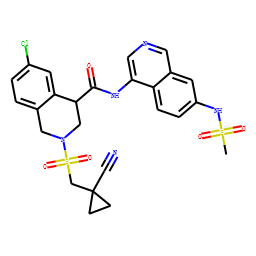

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw

# 输入 SMILES
smiles = "CS(=O)(=O)Nc1ccc2c(NC(=O)C3CN(S(=O)(=O)CC4(C#N)CC4)Cc4ccc(Cl)cc43)cncc2c1"  # 示例 SMILES，乙醇

# 将 SMILES 转换为分子对象
mol = Chem.MolFromSmiles(smiles)

img = Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(256, 256))
img